# Artificial Conditioning Vector Test

This notebook reuses the latest artificial dataset YAML emitted by `demo_artificial_non_streaming.ipynb` and the most recent saved artificial graph generator. It then checks whether graph-level conditioning steers generated samples toward the requested path length and node-label histogram.

In [10]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import json
import sys
from IPython.core.display import HTML
from pathlib import Path
import random
import warnings
import numpy as np

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

warnings.filterwarnings('ignore', message=r".*`isinstance\(treespec, LeafSpec\)` is deprecated.*")

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'conditional_node_field_graph_generator').is_dir():
        repo_root = candidate.resolve()
        break
else:
    raise RuntimeError(
        'Could not locate the NodeField repository from the current working directory. '
        'Start Jupyter from the repo root or the notebooks directory.'
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.extensions.synthetic import generate_artificial_dataset
from conditional_node_field_graph_generator.persistence import load_graph_generator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch version: 2.11.0+cu128
CUDA available: True


In [11]:
def latest_file(root, pattern):
    matches = sorted(Path(root).glob(pattern), key=lambda path: path.stat().st_mtime, reverse=True)
    if not matches:
        raise FileNotFoundError(f'No files matching {pattern!r} under {root}.')
    return matches[0]


def read_simple_yaml(path):
    config = {}
    for line_number, raw_line in enumerate(Path(path).read_text(encoding='utf-8').splitlines(), start=1):
        line = raw_line.strip()
        if not line or line.startswith('#'):
            continue
        if ':' not in line:
            raise ValueError(f'Invalid config line {line_number}: {raw_line!r}')
        key, value = line.split(':', 1)
        key = key.strip()
        value = value.strip()
        if not key:
            raise ValueError(f'Invalid empty config key on line {line_number}.')
        config[key] = None if value == '' else json.loads(value)
    return config


ARTIFICIAL_DATASET_CONFIG_PATH = latest_file(REPO_ROOT / 'notebooks', 'artificial-cycle-path-star*.yaml')
ARTIFICIAL_DATASET_CONFIG = read_simple_yaml(ARTIFICIAL_DATASET_CONFIG_PATH)
LATEST_ARTIFICIAL_GENERATOR_PATH = latest_file(SAVED_GENERATOR_ROOT, 'artificial-cycle-path-star*.pkl')

DATASET_SIZE = int(ARTIFICIAL_DATASET_CONFIG['num_graphs'])
CYCLE_LENGTH = ARTIFICIAL_DATASET_CONFIG['cycle_length']
NUM_CYCLES = ARTIFICIAL_DATASET_CONFIG.get('num_cycles', 1)
N_ITERATIONS = ARTIFICIAL_DATASET_CONFIG.get('n_iterations', 1)
PATH_LENGTH = ARTIFICIAL_DATASET_CONFIG['path_length']
NUM_RAYS = ARTIFICIAL_DATASET_CONFIG['num_rays']
RAY_LENGTH = ARTIFICIAL_DATASET_CONFIG['ray_length']
NODE_ALPHABET_SIZE = ARTIFICIAL_DATASET_CONFIG.get('node_alphabet_size', 1)
EDGE_ALPHABET_SIZE = ARTIFICIAL_DATASET_CONFIG.get('edge_alphabet_size', 1)
NODE_ALPHABET_KIND = ARTIFICIAL_DATASET_CONFIG.get('node_alphabet_kind', 'int')
EDGE_ALPHABET_KIND = ARTIFICIAL_DATASET_CONFIG.get('edge_alphabet_kind', 'int')
COMPONENT_SPECIFIC_ALPHABETS = ARTIFICIAL_DATASET_CONFIG.get('component_specific_alphabets', True)
RANDOM_SEED = ARTIFICIAL_DATASET_CONFIG.get('seed')

if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

print(f'Using latest artificial dataset config: {ARTIFICIAL_DATASET_CONFIG_PATH}')
print(ARTIFICIAL_DATASET_CONFIG)
print(f'Configured n_iterations: {N_ITERATIONS}')
print(f'Using latest artificial graph generator: {LATEST_ARTIFICIAL_GENERATOR_PATH}')


Using latest artificial dataset config: /cs0eth/home/fc334/code/NodeField/notebooks/artificial-cycle-path-star-n9000-c4-p2-6-r2x1-na3.yaml
{'num_graphs': 9000, 'cycle_length': 4, 'num_cycles': 1, 'path_length': [2, 6], 'num_rays': 2, 'ray_length': 1, 'node_alphabet_size': 3, 'edge_alphabet_size': 1, 'node_alphabet_kind': 'int', 'edge_alphabet_kind': 'int', 'component_specific_alphabets': True, 'seed': 42}
Configured n_iterations: 1
Using latest artificial graph generator: /cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators/artificial-cycle-path-star-n9000-c4-p-2-6-r2x1-d128-b128-e350.pkl


Loaded 9000 artificial graphs from artificial-cycle-path-star-n9000-c4-p2-6-r2x1-na3.yaml.
Node count min/median/max = 9/11/13
Edge count min/median/max = 9/11/13
Metadata: {'cycle_length': 4, 'num_cycles': 1, 'n_iterations': 1, 'path_length': 2, 'num_rays': 2, 'ray_length': 1, 'iteration_parameters': [{'cycle_length': 4, 'num_cycles': 1, 'path_length': 2, 'num_rays': 2, 'ray_length': 1}], 'node_alphabet_size': 3, 'edge_alphabet_size': 1, 'component_specific_alphabets': True, 'node_alphabets_by_component': {'cycle': [0, 1, 2], 'path': [3, 4, 5], 'star': [6, 7, 8]}, 'edge_alphabets_by_component': {'cycle': [0], 'path': [1], 'star': [2]}}


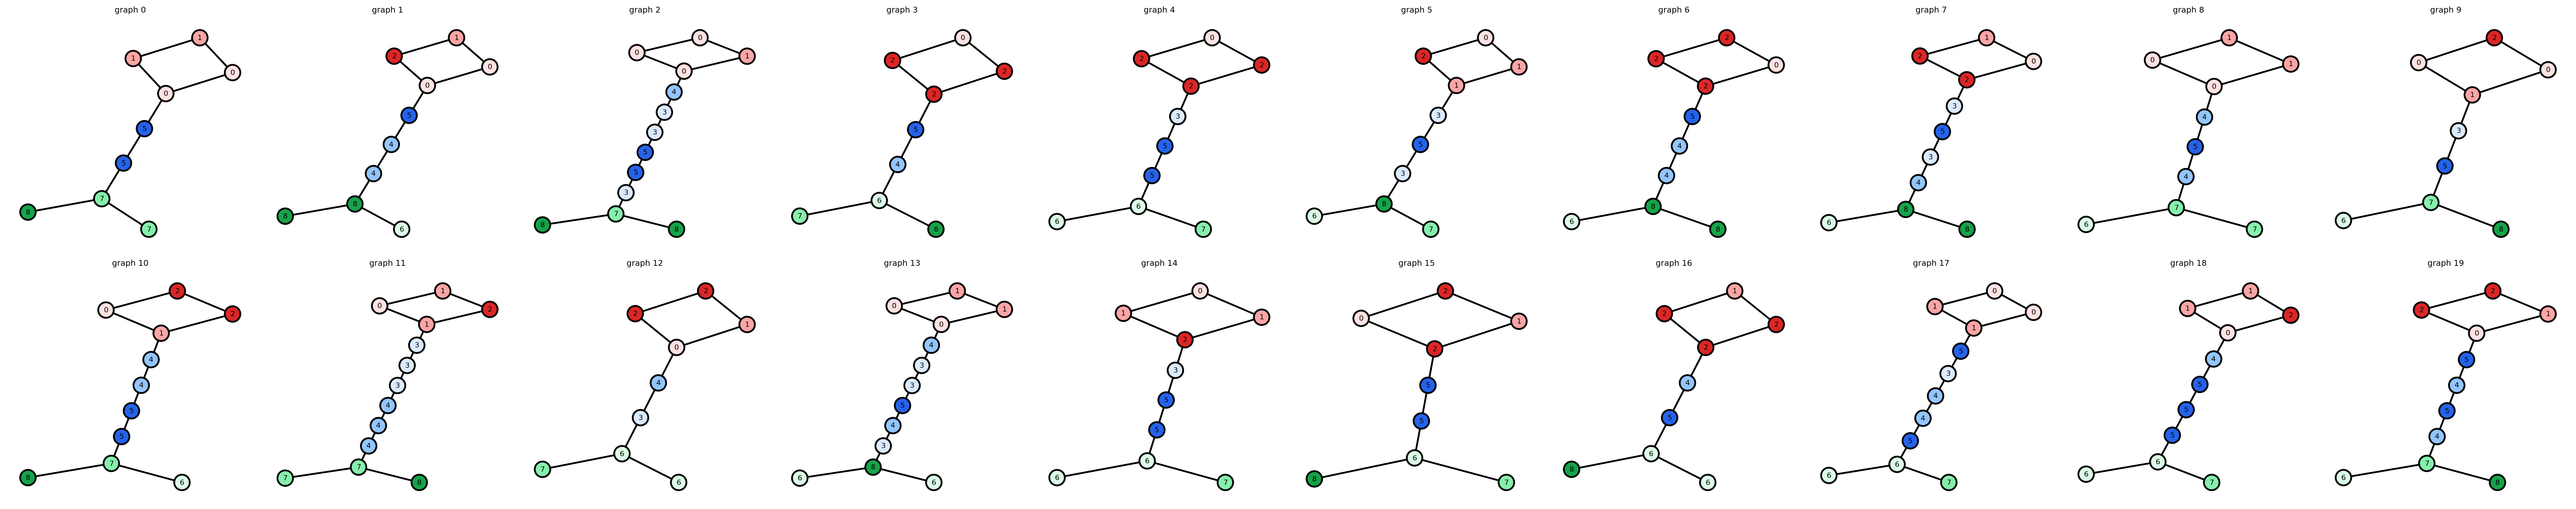

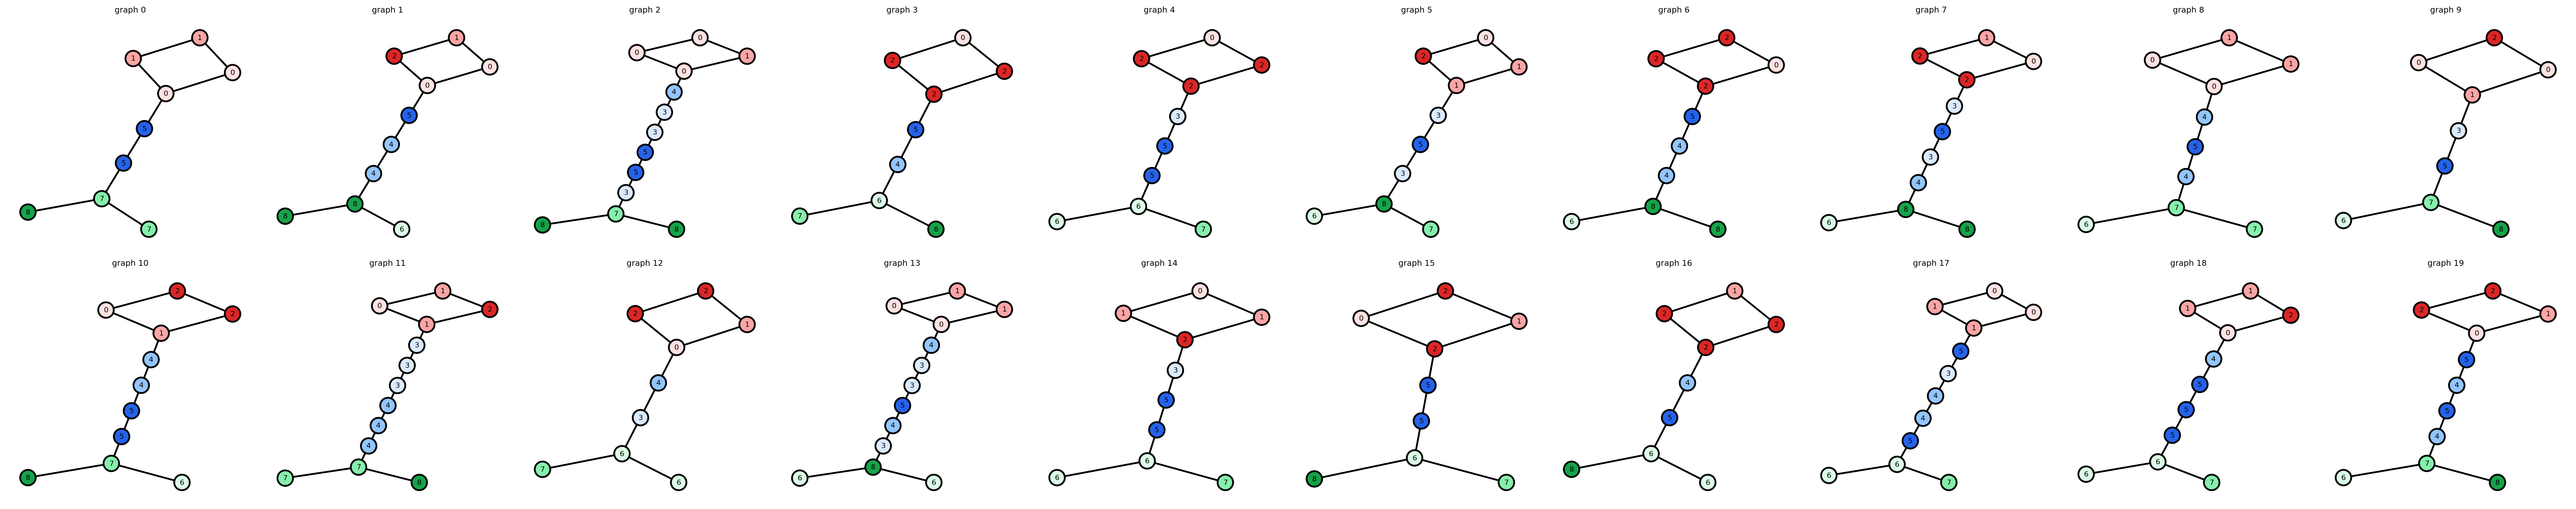

In [12]:
graphs, plot_artificial_graphs = generate_artificial_dataset(
    load_from_file=ARTIFICIAL_DATASET_CONFIG_PATH,
    save_config=False,
)

node_counts = np.array([graph.number_of_nodes() for graph in graphs])
edge_counts = np.array([graph.number_of_edges() for graph in graphs])
print(f'Loaded {len(graphs)} artificial graphs from {ARTIFICIAL_DATASET_CONFIG_PATH.name}.')
print(f'Node count min/median/max = {node_counts.min()}/{np.median(node_counts):.0f}/{node_counts.max()}')
print(f'Edge count min/median/max = {edge_counts.min()}/{np.median(edge_counts):.0f}/{edge_counts.max()}')
print('Metadata:', graphs[0].graph['metadata'])

plot_artificial_graphs(
    graphs[:20],
    n_cols=10,
    titles=[f'graph {idx}' for idx in range(min(20, len(graphs)))],
)

In [13]:
graph_generator = load_graph_generator(LATEST_ARTIFICIAL_GENERATOR_PATH)
print(f'Loaded graph generator: {LATEST_ARTIFICIAL_GENERATOR_PATH.name}')
print(f'Model name: {getattr(graph_generator, "model_name", None)}')
print(f'Fitted: {getattr(graph_generator, "is_fitted_", None)}')

Loaded graph generator: artificial-cycle-path-star-n9000-c4-p-2-6-r2x1-d128-b128-e350.pkl
/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators/artificial-cycle-path-star-n9000-c4-p-2-6-r2x1-d128-b128-e350.pkl
Loaded graph generator: artificial-cycle-path-star-n9000-c4-p-2-6-r2x1-d128-b128-e350.pkl
Model name: artificial-cycle-path-star-n9000-c4-p-2-6-r2x1-d128-b128-e350
Fitted: True


In [ ]:
n_samples = 3
sample_variants = graph_generator.sample(n_samples, return_decode_stages=True)

for variant_key, title_prefix in (
    ('raw', 'raw'),
    ('ilp', 'ilp'),
    ('oracle', 'oracle ilp'),
):
    variant_samples = sample_variants[variant_key]
    plot_artificial_graphs(
        variant_samples,
        n_cols=n_samples,
        titles=[f'{title_prefix} {idx}' for idx in range(len(variant_samples))],
    )

## Conditioning-vector steering checks

These cells sample from explicit input graphs through `graph_generator.conditional_sample(...)`, so each graph is encoded into a conditioning vector internally before decoding multiple generated graphs.

In [ ]:
from collections import Counter
import math
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt


EXPERIMENT_TYPE = 'path_length'
SAMPLES_PER_CONDITIONING_GRAPH = 32
EXAMPLE_SAMPLES_PER_CONDITION = 4
APPLY_FEASIBILITY_FILTERING = False
SCATTER_JITTER = 0.05


def graph_metadata_value(graph, key, default=np.nan):
    return graph.graph.get('metadata', {}).get(key, default)


def artificial_component_label_sets(conditioning_graph):
    metadata = conditioning_graph.graph.get('metadata', {})
    alphabets = metadata.get('node_alphabets_by_component', {}) or {}
    label_sets = {
        component: set(alphabets.get(component, []))
        for component in ('cycle', 'path', 'star')
    }

    if not any(label_sets.values()):
        for _, attrs in conditioning_graph.nodes(data=True):
            component = attrs.get('label_component')
            if component in label_sets:
                label_sets[component].add(attrs.get('label'))

    return label_sets


def artificial_component_nodes(graph, conditioning_graph):
    label_sets = artificial_component_label_sets(conditioning_graph)
    component_nodes = {component: [] for component in ('cycle', 'path', 'star')}
    for node, attrs in graph.nodes(data=True):
        label = attrs.get('label')
        for component, labels in label_sets.items():
            if label in labels:
                component_nodes[component].append(node)
                break
    return component_nodes


def artificial_iteration_parameters(graph):
    metadata = graph.graph.get('metadata', {})
    iteration_parameters = metadata.get('iteration_parameters')
    if iteration_parameters:
        return [
            {
                'cycle_length': int(unit.get('cycle_length', metadata.get('cycle_length', 0))),
                'num_cycles': int(unit.get('num_cycles', metadata.get('num_cycles', 1))),
                'path_length': int(unit.get('path_length', metadata.get('path_length', 0))),
                'num_rays': int(unit.get('num_rays', metadata.get('num_rays', 0))),
                'ray_length': int(unit.get('ray_length', metadata.get('ray_length', 0))),
            }
            for unit in iteration_parameters
        ]

    return [{
        'cycle_length': int(metadata.get('cycle_length', 0)),
        'num_cycles': int(metadata.get('num_cycles', 1)),
        'path_length': int(metadata.get('path_length', 0)),
        'num_rays': int(metadata.get('num_rays', 0)),
        'ray_length': int(metadata.get('ray_length', 0)),
    }]


def summarize_iteration_parameters(iteration_parameters):
    cycle_sizes = []
    ray_sizes = []
    for unit in iteration_parameters:
        cycle_length = int(unit.get('cycle_length', 0))
        num_cycles = int(unit.get('num_cycles', 0))
        path_length = int(unit.get('path_length', 0))
        num_rays = int(unit.get('num_rays', 0))
        ray_length = int(unit.get('ray_length', 0))
        if num_cycles > 0 and cycle_length >= 3:
            cycle_sizes.extend([cycle_length] * num_cycles)
        ray_sizes.extend([ray_length] * num_rays)

    path_lengths = [int(unit.get('path_length', 0)) for unit in iteration_parameters]
    num_rays_by_unit = [int(unit.get('num_rays', 0)) for unit in iteration_parameters]
    num_cycles_by_unit = [int(unit.get('num_cycles', 0)) for unit in iteration_parameters]

    return {
        'unit_count': len(iteration_parameters),
        'cycle_count': len(cycle_sizes),
        'configured_cycle_count': int(sum(num_cycles_by_unit)),
        'cycle_sizes': tuple(cycle_sizes),
        'cycle_size_median': float(np.median(cycle_sizes)) if cycle_sizes else np.nan,
        'cycle_size_min': min(cycle_sizes) if cycle_sizes else np.nan,
        'cycle_size_max': max(cycle_sizes) if cycle_sizes else np.nan,
        'path_length': int(sum(path_lengths)),
        'path_lengths': tuple(path_lengths),
        'ray_count': int(sum(num_rays_by_unit)),
        'ray_sizes': tuple(ray_sizes),
        'ray_size_median': float(np.median(ray_sizes)) if ray_sizes else np.nan,
        'ray_size_min': min(ray_sizes) if ray_sizes else np.nan,
        'ray_size_max': max(ray_sizes) if ray_sizes else np.nan,
    }


def is_path_like_subgraph(subgraph):
    n_nodes = subgraph.number_of_nodes()
    if n_nodes == 0:
        return True
    if not nx.is_connected(subgraph):
        return False
    degrees = [degree for _, degree in subgraph.degree()]
    if n_nodes == 1:
        return degrees == [0]
    return sorted(degrees).count(1) == 2 and max(degrees) <= 2


def analyze_path_components(graph, path_nodes):
    path_subgraph = graph.subgraph(path_nodes).copy()
    if path_subgraph.number_of_nodes() == 0:
        return {
            'path_component_count': 0,
            'path_component_sizes': tuple(),
            'path_components_are_valid': True,
        }
    component_subgraphs = [path_subgraph.subgraph(nodes).copy() for nodes in nx.connected_components(path_subgraph)]
    component_sizes = sorted(component.number_of_nodes() for component in component_subgraphs)
    return {
        'path_component_count': len(component_subgraphs),
        'path_component_sizes': tuple(component_sizes),
        'path_components_are_valid': bool(all(is_path_like_subgraph(component) for component in component_subgraphs)),
    }


def _choose_star_hubs(graph, star_subgraph, star_set):
    if star_subgraph.number_of_nodes() == 1:
        return list(star_subgraph.nodes()), True

    external_hubs = [
        node
        for node in star_subgraph.nodes()
        if any(neighbor not in star_set for neighbor in graph.neighbors(node))
    ]
    if external_hubs:
        return sorted(external_hubs, key=str), True

    degrees = dict(star_subgraph.degree())
    max_degree = max(degrees.values()) if degrees else 0
    if max_degree >= 3:
        return sorted([node for node, degree in degrees.items() if degree == max_degree], key=str), True

    if nx.is_tree(star_subgraph):
        centers = nx.center(star_subgraph)
        if len(centers) == 1:
            return centers, max_degree > 1

    hub = max(star_subgraph.nodes(), key=lambda node: (degrees.get(node, 0), graph.degree(node), str(node)))
    return [hub], False


def _trace_star_branch(star_subgraph, hub, neighbor, hub_set):
    branch_nodes = []
    previous = hub
    current = neighbor
    valid = True
    seen = {hub}
    while True:
        if current in seen:
            valid = False
            break
        seen.add(current)
        branch_nodes.append(current)
        next_nodes = [node for node in star_subgraph.neighbors(current) if node != previous and node not in hub_set]
        if len(next_nodes) == 0:
            break
        if len(next_nodes) > 1:
            valid = False
            branch_nodes.extend(next_nodes)
            break
        previous, current = current, next_nodes[0]
    return len(set(branch_nodes)), valid


def analyze_star_rays(graph, star_nodes):
    star_set = set(star_nodes)
    if not star_set:
        return {
            'ray_count': 0,
            'ray_sizes': tuple(),
            'ray_size_median': np.nan,
            'ray_size_min': np.nan,
            'ray_size_max': np.nan,
            'star_component_count': 0,
            'star_hub_count': 0,
            'star_hub_degrees': tuple(),
            'rays_are_valid': True,
        }

    star_subgraph_all = graph.subgraph(star_set).copy()
    ray_sizes = []
    hub_degrees = []
    valid = nx.is_forest(star_subgraph_all)
    hub_count = 0
    component_count = 0

    for component_nodes in nx.connected_components(star_subgraph_all):
        component_count += 1
        component = star_subgraph_all.subgraph(component_nodes).copy()
        hubs, hubs_are_unambiguous = _choose_star_hubs(graph, component, star_set)
        valid = bool(valid and hubs_are_unambiguous)
        hub_set = set(hubs)
        hub_count += len(hubs)
        for hub in hubs:
            hub_degrees.append(int(component.degree(hub)))
            for neighbor in component.neighbors(hub):
                if neighbor in hub_set:
                    continue
                branch_size, branch_valid = _trace_star_branch(component, hub, neighbor, hub_set)
                ray_sizes.append(branch_size)
                valid = bool(valid and branch_valid)

    return {
        'ray_count': len(ray_sizes),
        'ray_sizes': tuple(sorted(ray_sizes)),
        'ray_size_median': float(np.median(ray_sizes)) if ray_sizes else np.nan,
        'ray_size_min': min(ray_sizes) if ray_sizes else np.nan,
        'ray_size_max': max(ray_sizes) if ray_sizes else np.nan,
        'star_component_count': int(component_count),
        'star_hub_count': int(hub_count),
        'star_hub_degrees': tuple(sorted(hub_degrees)),
        'rays_are_valid': bool(valid),
    }


def analyze_artificial_graph(graph, conditioning_graph):
    component_nodes = artificial_component_nodes(graph, conditioning_graph)
    cycle_nodes = component_nodes['cycle']
    path_nodes = component_nodes['path']
    star_nodes = component_nodes['star']

    cycle_subgraph = graph.subgraph(cycle_nodes).copy()
    cycle_basis = nx.cycle_basis(cycle_subgraph) if cycle_subgraph.number_of_nodes() else []
    cycle_sizes = sorted(len(cycle) for cycle in cycle_basis)

    path_stats = analyze_path_components(graph, path_nodes)
    ray_stats = analyze_star_rays(graph, star_nodes)

    cycle_set = set(cycle_nodes)
    path_set = set(path_nodes)
    star_set = set(star_nodes)
    path_boundary_to_cycle = sum(
        1
        for node in path_set
        for neighbor in graph.neighbors(node)
        if neighbor in cycle_set
    )
    path_boundary_to_star = sum(
        1
        for node in path_set
        for neighbor in graph.neighbors(node)
        if neighbor in star_set
    )
    cycle_boundary_to_star = sum(
        1
        for node in cycle_set
        for neighbor in graph.neighbors(node)
        if neighbor in star_set
    )

    return {
        'total_nodes': graph.number_of_nodes(),
        'total_edges': graph.number_of_edges(),
        'cycle_label_nodes': len(cycle_nodes),
        'path_label_nodes': len(path_nodes),
        'star_label_nodes': len(star_nodes),
        'cycle_count': len(cycle_basis),
        'cycle_sizes': tuple(cycle_sizes),
        'cycle_size_median': float(np.median(cycle_sizes)) if cycle_sizes else np.nan,
        'cycle_size_min': min(cycle_sizes) if cycle_sizes else np.nan,
        'cycle_size_max': max(cycle_sizes) if cycle_sizes else np.nan,
        'cycle_component_count': nx.number_connected_components(cycle_subgraph) if cycle_subgraph.number_of_nodes() else 0,
        'cycles_are_valid': bool(all(size >= 3 for size in cycle_sizes)),
        'path_length': int(len(path_nodes)),
        'path_is_valid': bool(path_stats['path_components_are_valid']),
        'path_boundary_to_cycle': int(path_boundary_to_cycle),
        'path_boundary_to_star': int(path_boundary_to_star),
        'cycle_boundary_to_star': int(cycle_boundary_to_star),
        **path_stats,
        **ray_stats,
    }


def conditioning_artificial_stats(graph):
    metadata = graph.graph.get('metadata', {})
    stats = analyze_artificial_graph(graph, graph)
    iteration_parameters = artificial_iteration_parameters(graph)
    stats.update(summarize_iteration_parameters(iteration_parameters))
    stats['n_iterations'] = int(metadata.get('n_iterations', 1))
    stats['iteration_parameter_count'] = len(iteration_parameters)
    return stats


def node_label_counts(graph):
    return Counter(attrs.get('label') for _, attrs in graph.nodes(data=True))


def degree_counts(graph):
    return Counter(dict(graph.degree()).values())


def pick_conditioning_graphs_by_stat(graphs, stat_fn):
    selected_by_value = {}
    for graph in graphs:
        value = stat_fn(graph)
        if pd.isna(value):
            continue
        selected_by_value.setdefault(value, graph)
    if not selected_by_value:
        raise ValueError('No conditioning graphs matched the selected experiment.')
    return [selected_by_value[value] for value in sorted(selected_by_value)]


def conditioning_stats_value(graph, key):
    return conditioning_artificial_stats(graph)[key]


EXPERIMENT_REGISTRY = {
    'path_length': {
        'conditioning_value': lambda graph: conditioning_stats_value(graph, 'path_length'),
        'generated_metric': 'path_length',
        'valid_metric': 'path_is_valid',
        'x_label': 'conditioning graph total path-node count',
        'y_label': 'generated total path-node count',
        'title': 'Generated total path-node count vs conditioning path-node count',
    },
    'cycle_count': {
        'conditioning_value': lambda graph: conditioning_stats_value(graph, 'cycle_count'),
        'generated_metric': 'cycle_count',
        'valid_metric': 'cycles_are_valid',
        'x_label': 'conditioning graph total cycle count',
        'y_label': 'generated measured cycle count',
        'title': 'Generated cycle count vs total conditioning cycle count',
    },
    'cycle_size': {
        'conditioning_value': lambda graph: conditioning_stats_value(graph, 'cycle_size_median'),
        'generated_metric': 'cycle_size_median',
        'valid_metric': 'cycles_are_valid',
        'x_label': 'conditioning graph median cycle size',
        'y_label': 'generated median cycle size',
        'title': 'Generated cycle size vs conditioning cycle size',
    },
    'ray_count': {
        'conditioning_value': lambda graph: conditioning_stats_value(graph, 'ray_count'),
        'generated_metric': 'ray_count',
        'valid_metric': 'rays_are_valid',
        'x_label': 'conditioning graph configured ray count',
        'y_label': 'generated observable ray count',
        'title': 'Generated observable ray count vs conditioning ray count',
    },
    'ray_size': {
        'conditioning_value': lambda graph: conditioning_stats_value(graph, 'ray_size_median'),
        'generated_metric': 'ray_size_median',
        'valid_metric': 'rays_are_valid',
        'x_label': 'conditioning graph median configured ray size',
        'y_label': 'generated median observable ray size',
        'title': 'Generated ray size vs conditioning ray size',
    },
}

if EXPERIMENT_TYPE not in EXPERIMENT_REGISTRY:
    raise ValueError(f'Unknown EXPERIMENT_TYPE={EXPERIMENT_TYPE!r}. Choose one of {sorted(EXPERIMENT_REGISTRY)}.')

experiment = EXPERIMENT_REGISTRY[EXPERIMENT_TYPE]
conditioning_graphs = pick_conditioning_graphs_by_stat(graphs, experiment['conditioning_value'])
conditioning_values = [experiment['conditioning_value'](graph) for graph in conditioning_graphs]

print(f'Experiment: {EXPERIMENT_TYPE}')
print(f'Conditioning values: {conditioning_values}')
print(f'Generating {SAMPLES_PER_CONDITIONING_GRAPH} samples per conditioning graph once...')

conditioned_samples_by_graph = graph_generator.conditional_sample(
    conditioning_graphs,
    n_samples=SAMPLES_PER_CONDITIONING_GRAPH,
    apply_feasibility_filtering=APPLY_FEASIBILITY_FILTERING,
)

analysis_rows = []
conditioning_stats_by_graph = []
for conditioning_index, conditioning_graph in enumerate(conditioning_graphs):
    true_stats = conditioning_artificial_stats(conditioning_graph)
    true_value = conditioning_values[conditioning_index]
    conditioning_stats_by_graph.append(true_stats)
    generated_graphs = conditioned_samples_by_graph[conditioning_index]

    for generated_index, generated_graph in enumerate(generated_graphs):
        generated_stats = analyze_artificial_graph(generated_graph, conditioning_graph)
        row = {
            'conditioning_index': conditioning_index,
            'conditioning_value': true_value,
            'generated_index': generated_index,
            'n_generated_for_condition': len(generated_graphs),
        }
        row.update({f'conditioning_{key}': value for key, value in true_stats.items()})
        row.update({f'generated_{key}': value for key, value in generated_stats.items()})
        analysis_rows.append(row)

artificial_analysis_df = pd.DataFrame(analysis_rows)
display(artificial_analysis_df.head())

metric_column = f"generated_{experiment['generated_metric']}"
valid_column = f"generated_{experiment['valid_metric']}"
summary_rows = []
for conditioning_value, group in artificial_analysis_df.groupby('conditioning_value', sort=True):
    metric_values = pd.to_numeric(group[metric_column], errors='coerce').dropna()
    summary_rows.append({
        'conditioning_value': conditioning_value,
        'n_generated': len(group),
        'valid_rate': group[valid_column].mean() if valid_column in group else np.nan,
        'generated_median': metric_values.median() if not metric_values.empty else np.nan,
        'generated_q25': metric_values.quantile(0.25) if not metric_values.empty else np.nan,
        'generated_q75': metric_values.quantile(0.75) if not metric_values.empty else np.nan,
        'generated_mean': metric_values.mean() if not metric_values.empty else np.nan,
        'generated_std': metric_values.std(ddof=0) if not metric_values.empty else np.nan,
    })

experiment_summary_df = pd.DataFrame(summary_rows)
display(experiment_summary_df)

rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(7, 4))
scatter_x = artificial_analysis_df['conditioning_value'].to_numpy(dtype=float)
scatter_y = pd.to_numeric(artificial_analysis_df[metric_column], errors='coerce').to_numpy(dtype=float)
jitter = rng.uniform(-SCATTER_JITTER, SCATTER_JITTER, size=len(scatter_x)) if len(scatter_x) else []
ax.scatter(scatter_x + jitter, scatter_y, alpha=0.35, s=28, label='generated samples')
ax.errorbar(
    experiment_summary_df['conditioning_value'],
    experiment_summary_df['generated_median'],
    yerr=[
        experiment_summary_df['generated_median'] - experiment_summary_df['generated_q25'],
        experiment_summary_df['generated_q75'] - experiment_summary_df['generated_median'],
    ],
    fmt='o',
    color='black',
    capsize=4,
    label='median and IQR',
)
axis_values = pd.concat([
    artificial_analysis_df['conditioning_value'],
    pd.Series(scatter_y).dropna(),
])
if not axis_values.empty:
    min_axis = float(axis_values.min())
    max_axis = float(axis_values.max())
    ax.plot([min_axis, max_axis], [min_axis, max_axis], linestyle='--', color='gray', linewidth=1, label='ideal')
ax.set_xlabel(experiment['x_label'])
ax.set_ylabel(experiment['y_label'])
ax.set_title(experiment['title'])
ax.legend()
fig.tight_layout()
plt.show()

for conditioning_index, conditioning_graph in enumerate(conditioning_graphs):
    generated_examples = conditioned_samples_by_graph[conditioning_index][:EXAMPLE_SAMPLES_PER_CONDITION]
    plot_artificial_graphs(
        [conditioning_graph, *generated_examples],
        n_cols=1 + len(generated_examples),
        titles=[
            f'cond {EXPERIMENT_TYPE}={conditioning_values[conditioning_index]}',
            *[f'sample {idx}' for idx in range(len(generated_examples))],
        ],
    )


In [ ]:
HISTOGRAM_CONDITIONING_VALUE = (
    experiment_summary_df.sort_values('conditioning_value').iloc[-1]['conditioning_value']
)
_histogram_matches = [
    idx
    for idx, value in enumerate(conditioning_values)
    if value == HISTOGRAM_CONDITIONING_VALUE
]
if not _histogram_matches:
    raise RuntimeError(f'No cached conditioning graph found for value {HISTOGRAM_CONDITIONING_VALUE}.')

histogram_conditioning_index = _histogram_matches[0]
histogram_conditioning_graph = conditioning_graphs[histogram_conditioning_index]
histogram_samples = conditioned_samples_by_graph[histogram_conditioning_index]

if not histogram_samples:
    raise RuntimeError('No cached generated graphs are available for the selected conditioning graph.')

conditioning_counts = node_label_counts(histogram_conditioning_graph)
all_labels = sorted(
    set(conditioning_counts).union(
        label
        for generated_graph in histogram_samples
        for label in node_label_counts(generated_graph)
    ),
    key=lambda value: str(value),
)

generated_label_count_rows = []
for generated_graph in histogram_samples:
    counts = node_label_counts(generated_graph)
    generated_label_count_rows.append([counts.get(label, 0) for label in all_labels])

generated_label_count_mtx = np.asarray(generated_label_count_rows, dtype=float)
label_histogram_df = pd.DataFrame({
    'label': all_labels,
    'conditioning_count': [conditioning_counts.get(label, 0) for label in all_labels],
    'mean_generated_count': generated_label_count_mtx.mean(axis=0),
    'std_generated_count': generated_label_count_mtx.std(axis=0),
})
label_histogram_df['mean_abs_error'] = (
    label_histogram_df['mean_generated_count'] - label_histogram_df['conditioning_count']
).abs()
display(label_histogram_df)
print(f"Mean absolute label-count error: {label_histogram_df['mean_abs_error'].mean():.3f}")

conditioning_degree_counts = degree_counts(histogram_conditioning_graph)
all_degrees = sorted(
    set(conditioning_degree_counts).union(
        degree
        for generated_graph in histogram_samples
        for degree in degree_counts(generated_graph)
    )
)

generated_degree_count_rows = []
for generated_graph in histogram_samples:
    counts = degree_counts(generated_graph)
    generated_degree_count_rows.append([counts.get(degree, 0) for degree in all_degrees])

generated_degree_count_mtx = np.asarray(generated_degree_count_rows, dtype=float)
degree_histogram_df = pd.DataFrame({
    'degree': all_degrees,
    'conditioning_count': [conditioning_degree_counts.get(degree, 0) for degree in all_degrees],
    'mean_generated_count': generated_degree_count_mtx.mean(axis=0),
    'std_generated_count': generated_degree_count_mtx.std(axis=0),
})
degree_histogram_df['mean_abs_error'] = (
    degree_histogram_df['mean_generated_count'] - degree_histogram_df['conditioning_count']
).abs()
display(degree_histogram_df)
print(f"Mean absolute degree-count error: {degree_histogram_df['mean_abs_error'].mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = np.arange(len(all_labels))
width = 0.36
axes[0].bar(
    x - width / 2,
    label_histogram_df['conditioning_count'],
    width,
    label='conditioning',
)
axes[0].bar(
    x + width / 2,
    label_histogram_df['mean_generated_count'],
    width,
    yerr=label_histogram_df['std_generated_count'],
    capsize=3,
    label='generated mean',
)
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(label) for label in all_labels])
axes[0].set_xlabel('node label')
axes[0].set_ylabel('node count')
axes[0].set_title(f'Node-label histogram, condition={HISTOGRAM_CONDITIONING_VALUE}')
axes[0].legend()

x = np.arange(len(all_degrees))
axes[1].bar(
    x - width / 2,
    degree_histogram_df['conditioning_count'],
    width,
    label='conditioning',
)
axes[1].bar(
    x + width / 2,
    degree_histogram_df['mean_generated_count'],
    width,
    yerr=degree_histogram_df['std_generated_count'],
    capsize=3,
    label='generated mean',
)
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(degree) for degree in all_degrees])
axes[1].set_xlabel('node degree')
axes[1].set_ylabel('node count')
axes[1].set_title(f'Node-degree histogram, condition={HISTOGRAM_CONDITIONING_VALUE}')
axes[1].legend()

fig.tight_layout()
plt.show()

plot_artificial_graphs(
    [histogram_conditioning_graph, *histogram_samples[:6]],
    n_cols=7,
    titles=['conditioning', *[f'sample {idx}' for idx in range(min(6, len(histogram_samples)))]]
)
